# Práctica n°2

En este laboratorio se va desarrollar el uso de stemming y Lemmatización en textos. Dado un texto se procederá a predecir a tipo de noticia pertenece. Solamente trabaja con textos en español.
 Se usará el dataset de kaggle https://www.kaggle.com/datasets/kevinmorgado/spanish-news-classification

## Librerías


In [ ]:
!pip install -U scikit-learn

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

## Leer dataset

Cargo el dataset para luego ver el contenido

In [ ]:
df = pd.read_csv('practica_2.csv', encoding = 'UTF-8')

In [ ]:
df

,url,news,Type
0,https://www.larepublica.co/redirect/post/3201905,Durante el foro La banca articulador empresari...,Otra
1,https://www.larepublica.co/redirect/post/3210288,El regulador de valores de China dijo el domin...,Regulaciones
2,https://www.larepublica.co/redirect/post/3240676,En una industria históricamente masculina como...,Alianzas
3,https://www.larepublica.co/redirect/post/3342889,Con el dato de marzo el IPC interanual encaden...,Macroeconomia
4,https://www.larepublica.co/redirect/post/3427208,Ayer en Cartagena se dio inicio a la versión n...,Otra
...,...,...,...
1212,https://www.bbva.com/es/como-lograr-que-los-in...,En la vida de toda empresa emergente llega un ...,Innovacion
1213,https://www.bbva.com/es/podcast-como-nos-afect...,La espiral alcista de los precios continúa y g...,Macroeconomia
1214,https://www.larepublica.co/redirect/post/3253735,Las grandes derrotas nacionales son experienci...,Alianzas
1215,https://www.bbva.com/es/bbva-y-barcelona-healt...,BBVA ha alcanzado un acuerdo de colaboración c...,Innovacion


In [ ]:
print(f"Longitud: {len(df['news'][3])}\nTexto:{df['news'][3]}")

Longitud: 2674
Texto:Con el dato de marzo el IPC interanual encadena su decimoquinta tasa positiva consecutiva. La inflación publicada por el INE se ha mantenido igual respecto al avance del 30 de marzo y se sitúa 22 puntos por encima del dato de febrero que ascendió al 76.De esos 22 puntos de diferencia la mayor parte la colocó el grupo de la vivienda 09 puntos por la subida de la electricidad y el del transporte 07 puntos por el alza de los carburantes. También impulsaron el IPC de marzo el aumento de los precios de la restauración y los servicios de alojamiento y al encarecimiento generalizado de los alimentos especialmente del pescado y el marisco de la carne de las legumbres y hortalizas y de la leche el queso y los huevos.Sin tener en cuenta la rebaja del impuesto especial sobre la electricidad y las variaciones sobre otros impuestos el IPC interanual alcanzó en marzo 107 nueve décimas más que la tasa general del 98. Así lo refleja el IPC a impuestos constantes que el INE también

In [ ]:
print(df['Type'].value_counts())

Type
Macroeconomia     340
Alianzas          247
Innovacion        195
Regulaciones      142
Sostenibilidad    137
Otra              130
Reputacion         26
Name: count, dtype: int64


## Separación Fase de entranamiento y prueba

EL conjunto X contiene la columna de las noticias ```df['news']``` y el conjunto a predecir es el tipo de noticia ```df['Type']``` .

Una vez definido la variable dependiente(a predecir) e independiente se divide en conjunto en entrenamiento y prueba(train y test).

In [ ]:
X = df['news']
y = df['Type']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [ ]:
X_train

,news
886,El gobierno de México busca un pacto con empre...
170,La Fundación Asodisvalle fundada por Jeison Ar...
792,El Ministerio de Ciencia Tecnología e Innovaci...
872,La materia digital desde que nació no se detie...
287,Un indicador clave de los precios al consumido...
...,...
285,BBVA Open Innovation busca apoyar la transform...
86,El banco Bbva realizó una serie de recomendaci...
74,"Tradicionalmente, el mundo financiero ha estad..."
1065,Hasta antes de la aparición de la pandemia Avi...


In [ ]:
X_test

,news
1113,El de las tarifas de energía no es un tema nue...
643,Los precios de los productos en Colombia sigue...
1195,El año pasado la fabricación de productos farm...
625,La escasez de mujeres en el sector tecnológico...
1020,La Junta Directiva del Banco de la República l...
...,...
121,La inflación presentó una ligera disminución a...
409,Una brutal hola vendedora de acciones chinas c...
127,Los bancos siguen anunciando sus jornada de at...
941,El pasado mes de septiembre tuvo lugar la quin...


In [ ]:
y_train

,Type
886,Macroeconomia
170,Alianzas
792,Regulaciones
872,Regulaciones
287,Macroeconomia
...,...
285,Innovacion
86,Otra
74,Innovacion
1065,Alianzas


In [ ]:
y_test

,Type
1113,Macroeconomia
643,Macroeconomia
1195,Regulaciones
625,Innovacion
1020,Macroeconomia
...,...
121,Macroeconomia
409,Regulaciones
127,Otra
941,Sostenibilidad


Se puede ver que los valores son de tipo texto, con los datos tal cual como estan resultan un problema porque si se quiere predecir dado un texto a que categoría pertenece se debe transformar previamente para formar la ```f(x) = y```

----
## CountVectorizer

Convertir una colección de documentos de texto en una matriz de conteo de tokens.

Esta implementación produce una representación dispersa (sparse) de los conteos utilizando ```scipy.sparse.csr_matrix```.

**CountVectorizer:** Este objeto nos permitirá convertir el texto en una matriz numérica en los pasos posteriores.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()

### ¿Qué es una matriz de frecuencias?

Una matriz de frecuencias (o matriz de términos por documento) es una representación numérica de un conjunto de documentos en el que se cuentan cuántas veces aparece cada palabra en cada documento. Esta matriz se utiliza en el procesamiento de lenguaje natural (NLP) para convertir textos en datos numéricos que los modelos de Machine Learning puedan procesar.

Cada fila de la matriz representa un documento, y cada columna representa una palabra (o "término") del vocabulario. El valor en una celda específica de la matriz indica la frecuencia (el número de veces) que la palabra aparece en el documento correspondiente.

| Documento | token1 | token2 | token3 |
|-----------|--------|--------|--------|
| doc1      |   2    |   0    |   1    |
| doc2      |   0    |   1    |   1    |
| doc3      |   1    |   1    |   0    |

<br>
<br>

### ¿Cómo funciona CountVectorizer?

CountVectorizer es una clase de la biblioteca Scikit-learn que convierte un conjunto de textos (documentos) en una matriz de frecuencias de palabras. Este proceso se llama vectorización y es esencial para transformar texto en un formato que los modelos de Machine Learning puedan interpretar.
Proceso de CountVectorizer:

- **Tokenización:** Divide los textos en palabras (tokens).
-  **Construcción del vocabulario:** Crea un vocabulario con todas las palabras únicas de los textos.
-  **Conteo de frecuencias:** Calcula cuántas veces aparece cada palabra en cada documento.
- **Salida:** Genera una matriz dispersa (sparse matrix), donde cada fila es un documento y cada columna es una palabra del vocabulario, con el valor correspondiente al número de veces que aparece esa palabra en el documento.

In [ ]:
X_train_transformed = vectorizer.fit_transform(X_train)
X_test_transformed = vectorizer.transform(X_test)

Objetivo: Se entrena el vectorizador con los datos de entrenamiento (X_train), que consiste en textos. Este paso aprende el vocabulario de los textos.

fit_transform: Hace dos cosas:
- fit: Aprende el vocabulario y la frecuencia de las palabras en los datos de entrenamiento.
- transform: Convierte los textos en una matriz dispersa (sparse matrix), donde cada fila representa un documento y cada columna es una palabra del vocabulario, con un valor que indica la frecuencia de esa palabra en el documento.

In [ ]:
X_train_transformed

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 235062 stored elements and shape (973, 26938)>

In [ ]:
X_test_transformed

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 53235 stored elements and shape (244, 26938)>

In [ ]:
X_train_transformed_dense = X_train_transformed.toarray()

- Objetivo: Convierte la matriz dispersa en un arreglo denso (matriz completa de números), aunque no es siempre necesario.
- En muchos casos, las matrices dispersas son más eficientes en términos de memoria y procesamiento porque los textos suelen contener muchas palabras que no aparecen en un documento (la matriz será mayormente cero).
- Aquí simplemente estamos transformando la matriz dispersa a una matriz densa que ocupa más espacio en memoria.

In [ ]:
print(X_train_transformed_dense)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 2 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


Explicación:

Cada fila de la matriz corresponde a un documento, y cada columna a una palabra del vocabulario.
- 1° El primer documento ("El perro juega en el parque") se representa por la primera fila [0 0 0 2 0 1 0 1 1 0 0]. En esta fila:
  - El número 2 en la cuarta posición indica que la palabra "el" aparece dos veces.
  - El número 1 en la sexta posición indica que la palabra "juega" aparece una vez.
  - El número 1 en la octava posición indica que "perro" aparece una vez.
- El segundo documento ("El gato duerme en la casa") se representa por la segunda fila [0 1 1 2 1 0 1 0 0 0 0].
        "El" aparece dos veces.
        "Gato", "duerme" y "casa" aparecen una vez.

- El tercer documento ("El perro y el gato son amigos") se representa por la tercera fila [1 0 0 2 1 0 0 0 1 1 1].
        "Amigos", "perro", "gato", "el" y "son" aparecen una vez.





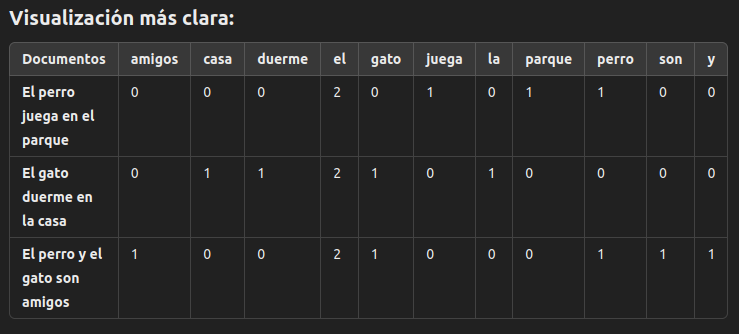

## Regresión Logística Multinomial
Es un modelo estadístico que se usa para predecir categorías múltiples (más de dos) a partir de datos de entrada.

La regresión logística multinomial es útil para situaciones en las
cuales desea poder clasificar sujetos basándose en los valores de un
conjunto de variables predictoras. Este tipo de regresión es similar a
la regresión logística, pero más general, ya que la variable dependiente
no está restringida a dos categorías.

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics

def obtener_metrica_accuracy_multinomialNB(X_train, y_train, x_test, y_test):
    model = MultinomialNB()
    model.fit(X_train, y_train)
    y_pred = model.predict(x_test)
    return metrics.accuracy_score(y_test, y_pred)

- **MultinomialNB:** Es un clasificador Naive Bayes diseñado para trabajar con datos de conteo de palabras (como los generados por CountVectorizer). Es especialmente útil para la clasificación de texto.
- **metrics:** Se utiliza para evaluar el rendimiento del modelo. metrics.accuracy_score mide la precisión, es decir, el porcentaje de predicciones correctas.

In [ ]:
accuracy_multinomial_simple = obtener_metrica_accuracy_multinomialNB(X_train_transformed, y_train, X_test_transformed, y_test)
print(accuracy_multinomial_simple)


0.75


```model.fit()``` entrena el modelo con los datos de entrenamiento

In [ ]:
# model.class_log_prior_

## Stemming

**Stemming** es un proceso del procesamiento de lenguaje natural (NLP) que consiste en reducir una palabra a su raíz o base (stem), eliminando los sufijos o terminaciones.

| Palabra original | stem(raiz)    |
|------------------|---------------|
| caminando	       |   camin       |
| caminarás        |   camin       |
| caminó           |   camin       |

In [ ]:
from nltk.stem import SnowballStemmer

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
stemmer= SnowballStemmer('spanish')

In [ ]:
def tokenize_and_stem(text):
    tokens = word_tokenize(text.lower())
    stems = [stemmer.stem(token) for token in tokens if token.isalpha()]
    return ' '.join(stems)

In [ ]:
df['news_stemmer']= df['news'].apply(tokenize_and_stem)

In [ ]:
df['news_stemmer']

,news_stemmer
0,durant el for la banc articul empresarial par ...
1,el regul de valor de chin dij el doming que bu...
2,en una industri histor masculin com lo es la a...
3,con el dat de marz el ipc interanual encaden s...
4,ayer en cartagen se dio inici a la version num...
...,...
1212,en la vid de tod empres emergent lleg un momen...
1213,la espiral alcist de los preci continu y gener...
1214,las grand derrot nacional son experient trauma...
1215,bbva ha alcanz un acuerd de colabor con barcel...


In [ ]:
print(f"Texto original\nLongitud: {len(df['news'][3])}\nTexto:{df['news'][3]}")

Texto original
Longitud: 2674
Texto:Con el dato de marzo el IPC interanual encadena su decimoquinta tasa positiva consecutiva. La inflación publicada por el INE se ha mantenido igual respecto al avance del 30 de marzo y se sitúa 22 puntos por encima del dato de febrero que ascendió al 76.De esos 22 puntos de diferencia la mayor parte la colocó el grupo de la vivienda 09 puntos por la subida de la electricidad y el del transporte 07 puntos por el alza de los carburantes. También impulsaron el IPC de marzo el aumento de los precios de la restauración y los servicios de alojamiento y al encarecimiento generalizado de los alimentos especialmente del pescado y el marisco de la carne de las legumbres y hortalizas y de la leche el queso y los huevos.Sin tener en cuenta la rebaja del impuesto especial sobre la electricidad y las variaciones sobre otros impuestos el IPC interanual alcanzó en marzo 107 nueve décimas más que la tasa general del 98. Así lo refleja el IPC a impuestos constantes que

In [ ]:
print(f"Texto Stemm\nLongitud: {len(df['news_stemmer'][3])}\nTexto:{df['news_stemmer'][3]}")


Texto Stemm
Longitud: 2146
Texto:con el dat de marz el ipc interanual encaden su decimoquint tas posit consecut la inflacion public por el ine se ha manten igual respect al avanc del de marz y se situ punt por encim del dat de febrer que ascend al esos punt de diferent la mayor part la coloc el grup de la viviend punt por la sub de la electr y el del transport punt por el alza de los carbur tambien impuls el ipc de marz el aument de los preci de la restaur y los servici de aloj y al encarec generaliz de los aliment especial del pesc y el marisc de la carn de las legumbr y hortaliz y de la lech el ques y los ten en cuent la rebaj del impuest especial sobr la electr y las variacion sobr otros impuest el ipc interanual alcanz en marz nuev decim mas que la tas general del asi lo reflej el ipc a impuest constant que el ine tambien public en el marc de esta inflacion subyacent sin aliment no elabor ni product energet aument en marz cuatr decim hast su valor mas alto desd septiembr de de este

### Ahora vamos a crear nuestro modelo con los datos "stimeados"

In [ ]:
X = df['news_stemmer']
y = df['Type']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
vectorizer = CountVectorizer()

X_train_transformed = vectorizer.fit_transform(X_train)
X_test_transformed = vectorizer.transform(X_test)


In [ ]:
accuracy_multinomial_stem = obtener_metrica_accuracy_multinomialNB(X_train_transformed, y_train, X_test_transformed, y_test)
print(accuracy_multinomial_stem)

0.8278688524590164


## Lemmatizacion

In [ ]:
import spacy
!python -m spacy download 'es_core_news_sm' -q
nlp = spacy.load('es_core_news_sm')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 28.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
nlp = spacy.load('es_core_news_sm')


In [ ]:
def lematizador_text(text):
    doc = nlp(text.lower())
    lemmas = [token.lemma_ for token in doc if token.is_alpha]
    return ' '.join(lemmas)

La función lematizador_text toma un texto de entrada y lo lematiza, es decir, reduce cada palabra a su forma básica (lemma)

In [ ]:
df['news_lemma']= df['news'].apply(lematizador_text)

In [ ]:
print(f"Texto Original\nLongitud: {len(df['news'][3])}\nTexto:{df['news'][3]}")
print(f"\nTexto Lemma\nLongitud: {len(df['news_lemma'][3])}\nTexto:{df['news_lemma'][3]}")


Texto Original
Longitud: 2674
Texto:Con el dato de marzo el IPC interanual encadena su decimoquinta tasa positiva consecutiva. La inflación publicada por el INE se ha mantenido igual respecto al avance del 30 de marzo y se sitúa 22 puntos por encima del dato de febrero que ascendió al 76.De esos 22 puntos de diferencia la mayor parte la colocó el grupo de la vivienda 09 puntos por la subida de la electricidad y el del transporte 07 puntos por el alza de los carburantes. También impulsaron el IPC de marzo el aumento de los precios de la restauración y los servicios de alojamiento y al encarecimiento generalizado de los alimentos especialmente del pescado y el marisco de la carne de las legumbres y hortalizas y de la leche el queso y los huevos.Sin tener en cuenta la rebaja del impuesto especial sobre la electricidad y las variaciones sobre otros impuestos el IPC interanual alcanzó en marzo 107 nueve décimas más que la tasa general del 98. Así lo refleja el IPC a impuestos constantes que

In [ ]:
X = df['news_lemma']
y = df['Type']

- train_test_split: Función que divide el conjunto de datos en dos partes: datos de entrenamiento (X_train, y_train) y datos de prueba (X_test, y_test).
- test_size=0.2: Significa que el 20% de los datos se usarán para pruebas y el 80% para entrenamiento.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
vectorizer = CountVectorizer()
X_train_transformed = vectorizer.fit_transform(X_train)
X_test_transformed = vectorizer.transform(X_test)


- MultinomialNB: Crea una instancia del clasificador Naive Bayes Multinomial, que es adecuado para datos de conteo como los generados por CountVectorizer.
- fit: Entrena el modelo con los datos transformados de entrenamiento (X_train_transformed) y las etiquetas correspondientes (y_train).

In [ ]:
accuracy_multinomial_lemma = obtener_metrica_accuracy_multinomialNB(X_train_transformed, y_train, X_test_transformed, y_test)
print(accuracy_multinomial_lemma)

0.7909836065573771


## Conclusiones
Viendo los resultados obtenidos luego le usar distintas tecnicas para predecir el tipo de noticia dado un texto, se puede obvservar que el mejor resultado se obtiene con el uso de Stemming. AL usar esta librería se redujo mucho más la cantidad de palabras que habia en un texto.

In [ ]:
## Conclusiones
print('Accuracy Simple', accuracy_multinomial_simple)
print('Accuracy Stemm', accuracy_multinomial_stem)
print('Accuracy Lemma', accuracy_multinomial_lemma)

Accuracy Simple 0.75
Accuracy Stemm 0.8278688524590164
Accuracy Lemma 0.7909836065573771
